In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Cargar Dataset

In [ ]:
df = pd.read_csv('../data/bolivia_dataset.csv', sep=";")

print(f'Shape: {df.shape}')
print(f'\nColumnas: {df.columns.tolist()}')
print(f'\nTipos de datos:')
print(df.dtypes)
df.head()

Shape: (100003, 66)

Columnas: ['transaction_id', 'bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_id', 'client_segment', 'channel', 'card_brand', 'pan_masked', 'pan_hash', 'MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE35_track2_data_masked', 'DE37_retrieval_reference_number', 'DE38_authorization_code', 'DE39_response_code', 'DE41_terminal_id', 'DE42_card_acceptor_id', 'DE43_card_acceptor_name_location', 'DE44_additional_response_data', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE54_additiona

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,...,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,...,500.12,True,8717.0,20,Tue,True,Approved,2012.51,TARIJA,False
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,...,1898.93,False,4.9,20,Tue,True,Approved,1096.46,LAPAZ,False
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,...,349.85,False,4.4,20,Tue,True,Approved,1528.37,SANTACRUZ,False
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002587,PLATINUM,ATM,VISA,479500******0288,...,345.58,True,3966.0,20,Tue,True,Approved,2483.34,SUCRE,False
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000087,PRIVATE,POS,VISA,479500******0249,...,118.90,False,348.0,20,Tue,True,NaN,1334.55,SUCRE,False


El dataset fue cargado correctamente especificando punto y coma (`;`) como separador, ya que el formato
original del archivo utiliza este delimitador en lugar de la coma estándar. El resultado fue un DataFrame
de 100,003 transacciones y 66 variables, que incluyen campos nativos del estándar ISO 8583, metadatos
del cliente y etiquetas de fraude. Los tipos de datos son mixtos: variables numéricas (float64, int),
booleanas (`approved`, `is_fraud`) y categóricas (object). Se identificaron valores nulos en algunas
columnas como `card_brand` y `response_description`, lo cual deberá considerarse en la etapa de
preprocesamiento.

# Variable Objetivo

In [6]:
target_candidates = [c for c in df.columns if c.lower() in ['fraud', 'isfraud', 'is_fraud', 'label', 'class', 'target', 'fraude']]
target_col = target_candidates[0] if target_candidates else df.columns[-1]
print(f"Variable objetivo detectada: '{target_col}'")

Variable objetivo detectada: 'is_fraud'


In [7]:
counts = df[target_col].value_counts()
pcts   = df[target_col].value_counts(normalize=True) * 100

dist = pd.DataFrame({
    'Clase': counts.index,
    'Conteo': counts.values,
    'Porcentaje': pcts.values.round(4)
})
print(dist.to_string(index=False))

 Clase  Conteo  Porcentaje
 False   95084     95.0811
  True    4919      4.9189


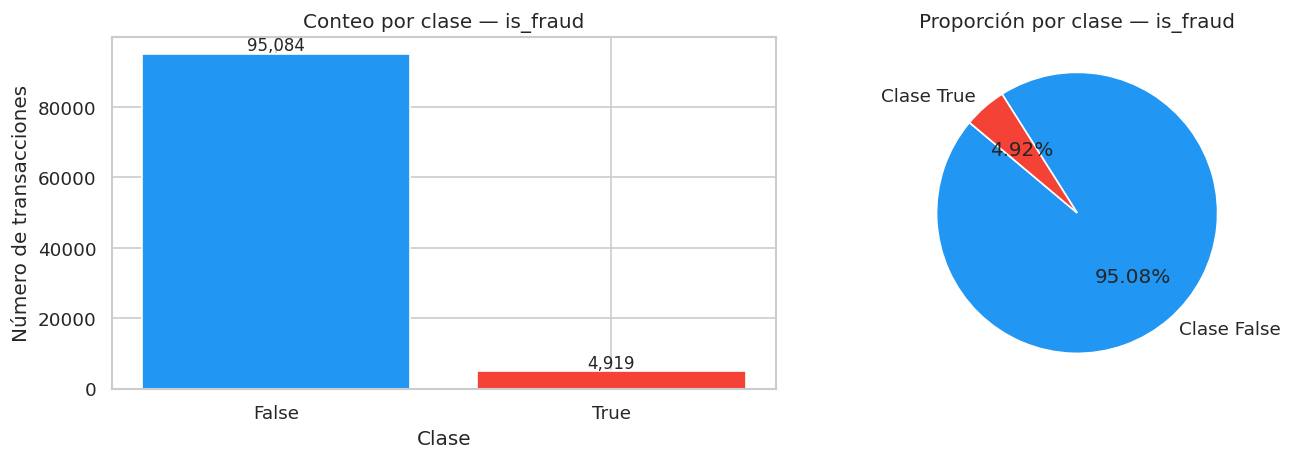

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#F44336']

# Bar chart
axes[0].bar(counts.index.astype(str), counts.values, color=colors[:len(counts)])
axes[0].set_title(f'Conteo por clase — {target_col}')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de transacciones')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + counts.max()*0.01, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(
    counts.values,
    labels=[f'Clase {c}' for c in counts.index],
    autopct='%1.2f%%',
    colors=colors[:len(counts)],
    startangle=140
)
axes[1].set_title(f'Proporción por clase — {target_col}')

plt.tight_layout()
plt.show()

La variable objetivo del dataset es `is_fraud`, de tipo booleano con valores `True` (fraude) y `False`
(legítima). La detección fue automática buscando nombres estándar en las columnas. La distribución
muestra 95,084 transacciones legítimas (95.08%) contra 4,919 fraudulentas (4.92%), lo cual evidencia
un desbalanceo marcado entre clases. Las visualizaciones de barras y torta confirman visualmente esta
proporción, donde la clase minoritaria (fraude) representa menos de 1 de cada 20 transacciones,
estableciendo el punto de partida para las estrategias de balanceo que se aplicarán más adelante.

# Metrica de Desbalanceo

In [9]:
majority = counts.max()
minority = counts.min()
imbalance_ratio = majority / minority

print(f'Clase mayoritaria : {counts.idxmax()} — {majority:,} muestras ({pcts[counts.idxmax()]:.2f}%)')
print(f'Clase minoritaria  : {counts.idxmin()} — {minority:,} muestras ({pcts[counts.idxmin()]:.2f}%)')
print(f'Imbalance ratio    : {imbalance_ratio:.2f}:1')

if imbalance_ratio < 2:
    nivel = 'Balanceado'
elif imbalance_ratio < 10:
    nivel = 'Desbalanceo moderado'
elif imbalance_ratio < 100:
    nivel = 'Desbalanceo severo'
else:
    nivel = 'Desbalanceo extremo'

print(f'Nivel de desbalanceo: {nivel}')

Clase mayoritaria : False — 95,084 muestras (95.08%)
Clase minoritaria  : True — 4,919 muestras (4.92%)
Imbalance ratio    : 19.33:1
Nivel de desbalanceo: Desbalanceo severo


Se calcularon las métricas de desbalanceo para cuantificar la diferencia entre clases. El ratio de
desbalanceo resultó en 19.33:1, lo que significa que por cada transacción fraudulenta existen casi
20 transacciones legítimas. Este nivel es clasificado como **desbalanceo severo**, lo cual tiene
implicaciones directas sobre el entrenamiento del modelo: un clasificador naive que prediga siempre
`False` alcanzaría un 95% de accuracy sin detectar ningún fraude. Este hallazgo justifica el uso de
métricas de evaluación alternativas como F1-score, Precision-Recall y AUC-ROC, así como técnicas
de compensación del desbalanceo durante el entrenamiento.

# Distribucion de Variables Numericas por Clase

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore').tolist()
print(f'Variables numéricas ({len(num_cols)}): {num_cols}\n')

df.groupby(target_col)[num_cols].describe().T

Variables numéricas (35): ['MTI', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE39_response_code', 'DE48_additional_data', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE54_additional_amounts', 'DE56_original_data', 'DE58_authorizing_agent_id', 'DE61_pos_extended_data', 'DE100_receiving_institution_id', 'DE103_account_id_2', 'amount_local', 'amount_tx_currency', 'amount_usd', 'distance_from_home_km', 'hour_local', 'client_baseline_amount']



is_fraud                         False    True 
MTI                    count  95084.00  4919.00
                       mean     100.00   100.00
                       std        0.00     0.00
                       min      100.00   100.00
                       25%      100.00   100.00
...                                ...      ...
client_baseline_amount min      600.00   600.00
                       25%     1097.22  1110.17
                       50%     1570.60  1548.42
                       75%     2038.37  2017.25
                       max     2498.92  2497.66

[280 rows x 2 columns]

In [11]:
means = df.groupby(target_col)[num_cols].mean()
diff = (means.loc[True] - means.loc[False]).abs()
diff_pct = (diff / means.loc[False].replace(0, np.nan) * 100).round(2)

resumen = pd.DataFrame({
    'mean_legit': means.loc[False].round(4),
    'mean_fraud': means.loc[True].round(4),
    'diff_abs': diff.round(4),
    'diff_pct': diff_pct
}).sort_values('diff_pct', ascending=False)

print(resumen.head(15).to_string())

                                  mean_legit    mean_fraud      diff_abs  diff_pct
DE39_response_code              1.033700e+00  1.072740e+01  9.693700e+00    937.77
amount_tx_currency              1.173115e+04  6.330103e+04  5.156988e+04    439.60
DE4_amount_transaction          1.173115e+06  6.330103e+06  5.156988e+06    439.60
amount_usd                      3.959129e+02  1.101323e+03  7.054101e+02    178.17
amount_local                    2.731799e+03  7.599129e+03  4.867330e+03    178.17
DE6_amount_cardholder_billing   2.731799e+05  7.599129e+05  4.867330e+05    178.17
distance_from_home_km           1.720966e+03  2.894743e+03  1.173776e+03     68.20
DE61_pos_extended_data          2.685010e+01  4.466390e+01  1.781380e+01     66.35
DE25_pos_condition_code         2.684660e+01  4.464420e+01  1.779760e+01     66.29
DE49_currency_code_transaction  2.284969e+02  3.526465e+02  1.241496e+02     54.33
DE19_acquirer_country_code      1.877668e+02  2.771014e+02  8.933470e+01     47.58
DE3_

/tmp/ipykernel_1236/42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1236/42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1236/42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1236/42062771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1236/42062771.py:10: FutureWarning: 

Passing `pa

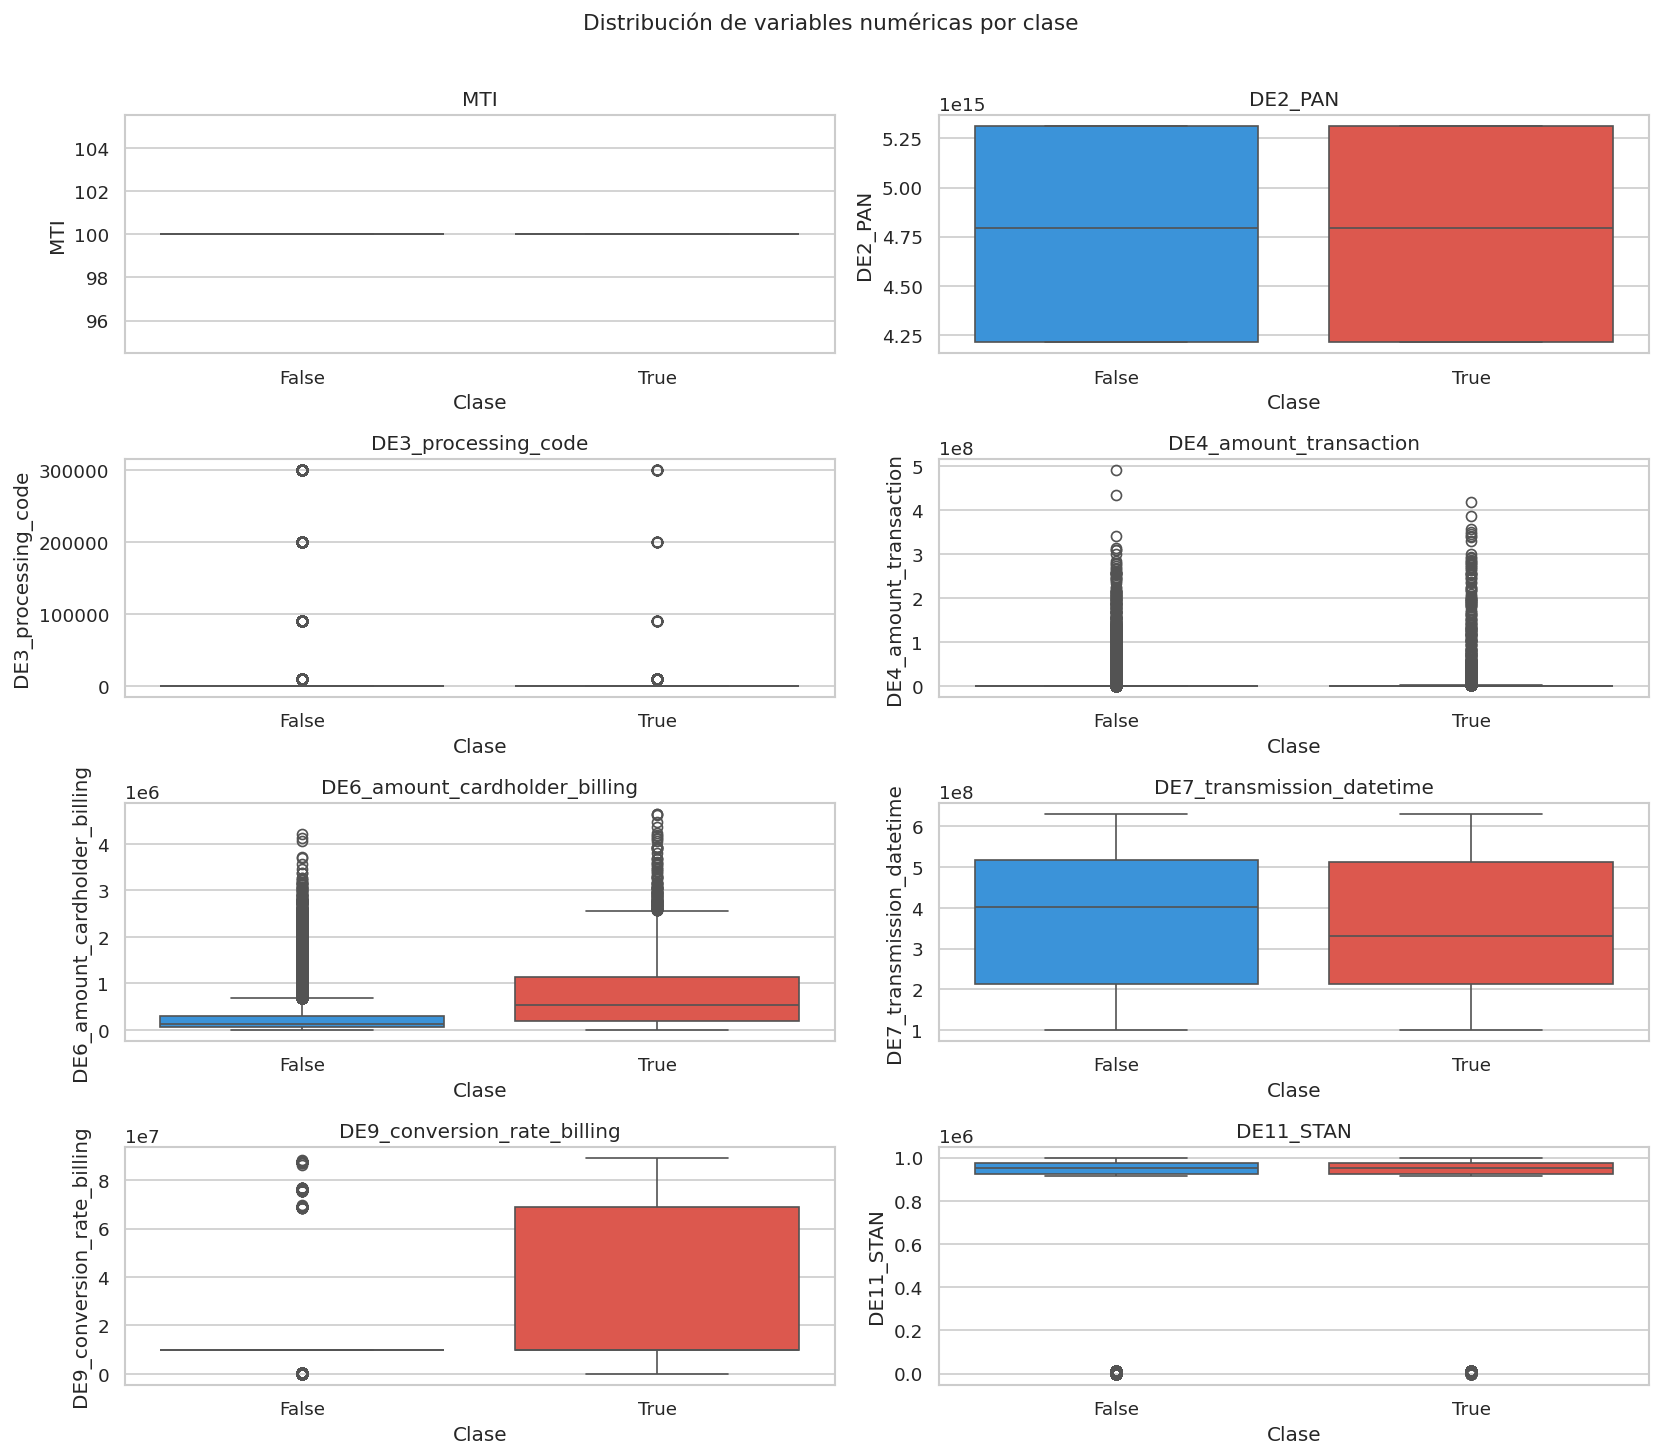

In [12]:
plot_cols = num_cols[:8]
n = len(plot_cols)
cols_grid = 2
rows_grid = (n + 1) // cols_grid

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(14, rows_grid * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(
        data=df, x=target_col, y=col,
        palette=['#2196F3', '#F44336'],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Clase')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Se analizaron 35 variables numéricas comparando sus distribuciones entre transacciones legítimas y
fraudulentas. Las variables con mayor poder discriminativo son las relacionadas al monto: `amount_usd`,
`amount_local` y `DE6_amount_cardholder_billing` muestran una diferencia de medias de ~178%, indicando
que las transacciones fraudulentas son en promedio casi 3 veces más altas en valor. La `distance_from_home_km`
también presenta una diferencia del 68%, confirmando que el fraude ocurre más lejos del domicilio del
cliente. Por otro lado, `DE39_response_code` muestra una diferencia del 937% pero debe tratarse con
cautela ya que podría representar data leakage al ser un campo generado post-transacción. Variables como
`MTI` y `DE11_STAN` son constantes o identificadores y no aportan valor predictivo al modelo.

# Distribucion de Variables Categoricas por Clase

In [13]:
cat_cols = ['channel', 'card_brand', 'DE22_pos_entry_mode', 'DE25_pos_condition_code', 'bank_tier', 'client_segment']

for col in cat_cols:
    fraud_rate = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    print(fraud_rate.round(4))


channel:
channel
ECOM    0.0802
ATM     0.0284
POS     0.0224
MOTO    0.0105
Name: is_fraud, dtype: float64

card_brand:
card_brand
MASTERCARD    0.0513
VISA          0.0482
Name: is_fraud, dtype: float64

DE22_pos_entry_mode:
DE22_pos_entry_mode
22    0.9841
81    0.0802
71    0.0498
51    0.0176
72    0.0107
10    0.0105
21    0.0104
Name: is_fraud, dtype: float64

DE25_pos_condition_code:
DE25_pos_condition_code
59    0.0802
0     0.0239
8     0.0105
1     0.0102
Name: is_fraud, dtype: float64

bank_tier:
bank_tier
vip    0.0492
Name: is_fraud, dtype: float64

client_segment:
client_segment
PRIVATE     0.0517
PLATINUM    0.0492
BLACK       0.0463
INFINITE    0.0429
Name: is_fraud, dtype: float64


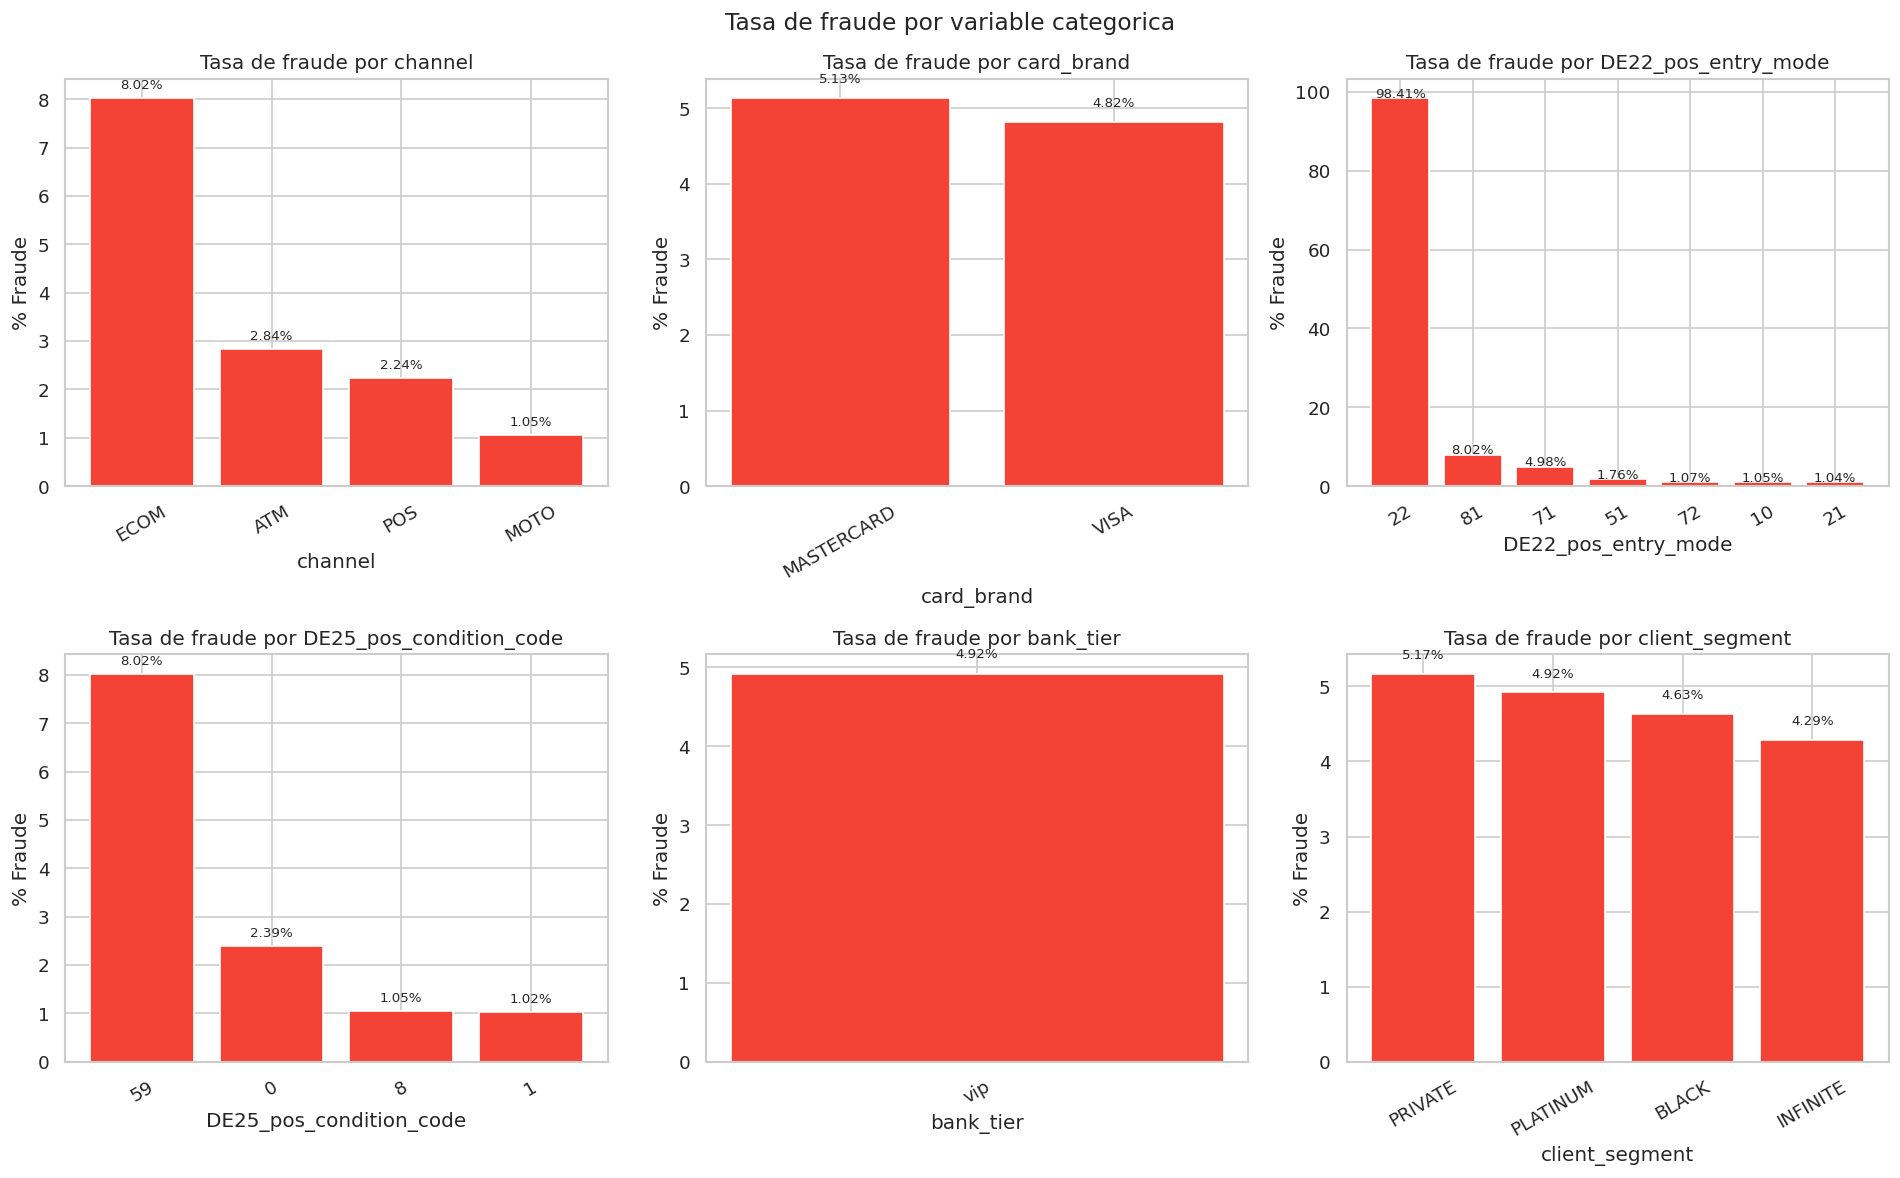

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    axes[i].bar(fraud_rate.index.astype(str), fraud_rate.values * 100, color='#F44336')
    axes[i].set_title(f'Tasa de fraude por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% Fraude')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(fraud_rate.values):
        axes[i].text(j, v * 100 + 0.2, f'{v*100:.2f}%', ha='center', fontsize=8)

plt.suptitle('Tasa de fraude por variable categorica', fontsize=14)
plt.tight_layout()
plt.show()

El análisis de variables categóricas revela patrones claros asociados al fraude. El canal ECOM presenta
la tasa más alta con 8.02%, confirmando que el fraude online es el patrón dominante en este dataset.
`DE22_pos_entry_mode = 22` muestra una tasa de 98.41%, lo que lo convierte en una señal casi perfecta
de fraude y debe evaluarse como posible data leakage antes de incluirlo en el modelo. `bank_tier` tiene
un único valor (`vip`), por lo que es una variable constante que no aporta capacidad discriminativa y
puede descartarse. `card_brand` y `client_segment` muestran diferencias mínimas entre categorías, por
lo que su aporte al modelo será limitado comparado con variables de canal y modo de entrada.

# Distribucion Temporal del Fraude

In [18]:
df['DE15_settlement_date'] = df['DE15_settlement_date'].fillna(0).astype(int).astype(str).str.zfill(4)
df['month_parsed'] = df['DE15_settlement_date'].str[:2].astype(int)

monthly = df.groupby('month_parsed').agg(
    total=('is_fraud', 'count'),
    fraudes=('is_fraud', 'sum')
).reset_index()
monthly['tasa_fraude'] = (monthly['fraudes'] / monthly['total'] * 100).round(4)

print(monthly.to_string(index=False))

 month_parsed  total  fraudes  tasa_fraude
            0    982       53       5.3971
            1  16658      824       4.9466
            2  15467      760       4.9137
            3  16968      881       5.1921
            4  16404      813       4.9561
            5  17054      841       4.9314
            6  16470      747       4.5355


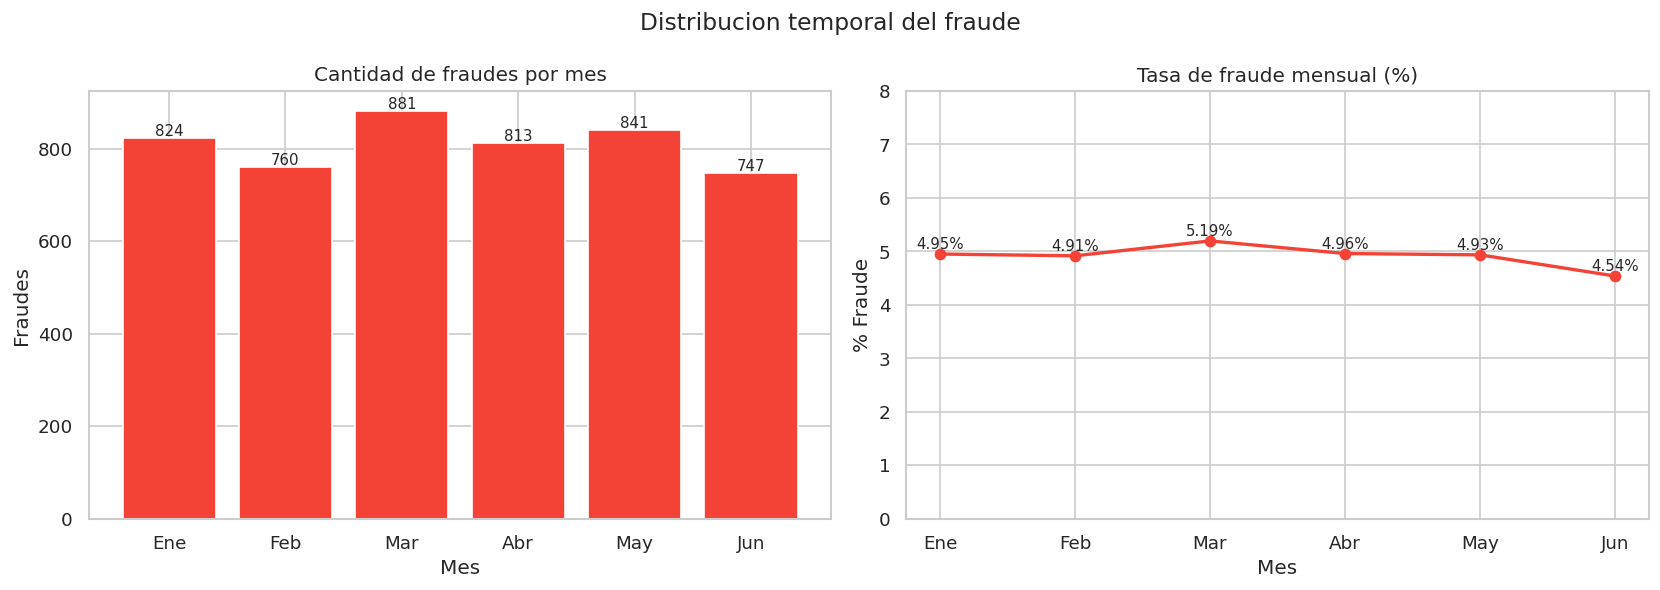

In [19]:
monthly_clean = monthly[monthly['month_parsed'] > 0].copy()
month_names = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun'}
monthly_clean['mes'] = monthly_clean['month_parsed'].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_clean['mes'], monthly_clean['fraudes'], color='#F44336')
axes[0].set_title('Cantidad de fraudes por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Fraudes')
for i, v in enumerate(monthly_clean['fraudes']):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

axes[1].plot(monthly_clean['mes'], monthly_clean['tasa_fraude'], marker='o', color='#F44336', linewidth=2)
axes[1].set_title('Tasa de fraude mensual (%)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('% Fraude')
axes[1].set_ylim(0, 8)
for i, v in enumerate(monthly_clean['tasa_fraude']):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.suptitle('Distribucion temporal del fraude', fontsize=14)
plt.tight_layout()
plt.show()

Se analizó la distribución temporal del fraude utilizando la variable `DE15_settlement_date` para
extraer el mes de cada transacción. La tasa de fraude mensual se mantiene estable entre 4.54% y 5.19%
a lo largo de los seis meses del dataset, sin picos ni caídas abruptas que indiquen cambios de patrón.
Marzo registra la tasa más alta (5.19%) y Junio la más baja (4.54%), siendo este último el mes
designado como conjunto de test. La estabilidad temporal es una señal positiva para el modelo, ya que
indica ausencia de drift temporal significativo entre entrenamiento y evaluación, lo que favorece la
capacidad de generalización del clasificador.

# Decision de Estrategia de Balanceo

In [20]:
total = len(df)
n_fraud = df[target_col].sum()
n_legit = total - n_fraud
scale_pos_weight = n_legit / n_fraud

print(f"Total transacciones  : {total:,}")
print(f"Legitimas            : {n_legit:,}")
print(f"Fraudulentas         : {n_fraud:,}")
print(f"scale_pos_weight     : {scale_pos_weight:.4f}")
print()
print("Estrategia seleccionada: scale_pos_weight en LightGBM")
print("Motivo: desbalanceo severo 19.33:1, no se aplica SMOTE para")
print("evitar introducir ruido sintetico sobre datos ya sinteticos.")

Total transacciones  : 100,003
Legitimas            : 95,084
Fraudulentas         : 4,919
scale_pos_weight     : 19.3299

Estrategia seleccionada: scale_pos_weight en LightGBM
Motivo: desbalanceo severo 19.33:1, no se aplica SMOTE para
evitar introducir ruido sintetico sobre datos ya sinteticos.


Dado el desbalanceo severo de 19.33:1, se evaluaron tres estrategias posibles para compensarlo durante
el entrenamiento. La primera es `scale_pos_weight = 19.33` en LightGBM, que penaliza los errores sobre
la clase minoritaria sin modificar los datos. La segunda es oversampling con SMOTE, que genera muestras
sintéticas de la clase fraude, aunque en este caso debe aplicarse con cautela ya que el dataset original
ya es sintético. La tercera es undersampling aleatorio de la clase mayoritaria, reduciendo las legítimas
para equilibrar las clases, con el costo de perder información. Como punto de partida se utilizará
`scale_pos_weight`, y se explorarán oversampling y undersampling como alternativas durante la etapa de
optimización para comparar su impacto en la reducción de falsos positivos.

# Conclusión del EDA de Bolivia

El análisis exploratorio reveló un dataset con desbalanceo severo de 19.33:1, donde el fraude representa
solo el 4.92% de las transacciones. Las variables con mayor poder discriminativo son el monto de la
transacción (diferencia de ~178% entre clases), `distance_from_home_km` (68%) y el canal ECOM (8.02%
de tasa de fraude). Se identificó `DE22_pos_entry_mode = 22` y `DE39_response_code` como posibles
casos de data leakage que deberán excluirse o tratarse con cuidado. La distribución temporal es estable
entre meses, lo que favorece la generalización del modelo sobre Junio como set de test. Como estrategia
de balanceo se utilizará `scale_pos_weight = 19.33` como línea base, explorando oversampling y
undersampling como alternativas durante la etapa de optimización.